## Predicting Heart Disease
### **Objective:** To build a machine learning model that can predict the presence of heart disease in a patient based on 13 medical attributes.
### **Dataset:** Heart Disease Dataset from the UCI Machine Learning Repository.
### **Source:** https://archive.ics.uci.edu/ml/datasets/heart+disease
### **Project Pipeline:**
### 1.  **Setup:** Import libraries.
### 2.  **Load Data:** Load the dataset from its URL. The data has no header!
### 3.  **Data Cleaning:** Handle missing values, which are marked with a '?'.
### 4.  **Feature Engineering:** The target variable (heart disease) is 0-4. We will convert this to a binary 0 (no disease) vs. 1 (has disease).
### 5.  **Exploratory Data Analysis (EDA):** Visualize our key features.
### 6.  **Preprocessing:** Split data and scale features.
### 7.  **Model Training:** Train two models:
###     - Model 1: Logistic Regression (a simple, interpretable model).
###     - Model 2: Random Forest (a more complex, powerful model).
### 8.  **Model Evaluation:** Compare the models using accuracy and confusion matrices.

### 1. SETUP: Import Libraries

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2. LOAD DATA

In [34]:
# We are loading the 'processed.cleveland.data' file.
# This file is a CSV, but it has no header row (no column names).
# We must provide the column names manually based on the dataset documentation.
print("Loading data from UCI Repository...")

# Column names from the dataset documentation
col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# URL for the raw data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Load the data
df = pd.read_csv(url, header=None, names=col_names)

Loading data from UCI Repository...


### 3. DATA CLEANING

In [35]:
# This is a "real" dataset, so it has missing values.
# In this dataset, missing values are coded as '?'.
print("\n--- Data Head (Raw) ---")
print(df.head())


--- Data Head (Raw) ---
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  


In [36]:
# Let's see the data types. We'll notice some are 'object' (text)
# when they should be numbers. This is because of the '?' character.
print("\n--- Data Info (Raw) ---")
df.info()


--- Data Info (Raw) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [37]:
# Replace '?' with numpy's 'Not a Number' (NaN)
df.replace('?', np.nan, inplace=True)

In [38]:
# Now, we can see how many values are missing in each column
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [39]:
# For this project, the simplest approach is to drop rows with any missing values. 'ca' (number of major vessels) and 'thal' have a few.
print(f"\nOriginal number of rows: {len(df)}")
df_cleaned = df.dropna()
print(f"Number of rows after dropping NaNs: {len(df_cleaned)}")


Original number of rows: 303
Number of rows after dropping NaNs: 297


In [40]:
# Now we need to convert the 'object' columns to numbers
# We will convert all columns to numeric, as they should be.
# Make an explicit copy to avoid SettingWithCopyWarning
df_cleaned = df_cleaned.copy()

# Now safely convert all columns to numeric
for col in df_cleaned.columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

print("\n--- Data Info (Cleaned) ---")
df_cleaned.info()


--- Data Info (Cleaned) ---
<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


### 4. FEATURE ENGINEERING

In [41]:
# The 'target' column is 0 (no disease) or 1, 2, 3, 4 (levels of disease).
# We want to simplify this to a binary classification problem:
# 0 = No Disease
# 1 = Has Disease
print("\n--- Original Target Values ---")
print(df_cleaned['target'].value_counts())


--- Original Target Values ---
target
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64


In [42]:
# We use .loc to create a new column, 'has_disease'
# If target > 0, set to 1. Otherwise, it's 0.
df_cleaned['has_disease'] = (df_cleaned['target'] > 0).astype(int)

In [43]:
# Drop the original 'target' column
df_cleaned = df_cleaned.drop('target', axis=1)

In [44]:
print("\n--- New Binary Target 'has_disease' ---")
print(df_cleaned['has_disease'].value_counts())


--- New Binary Target 'has_disease' ---
has_disease
0    160
1    137
Name: count, dtype: int64


### 5. EXPLORATORY DATA ANALYSIS (EDA)


Generating EDA plots...
Saved heart_disease_histograms.png


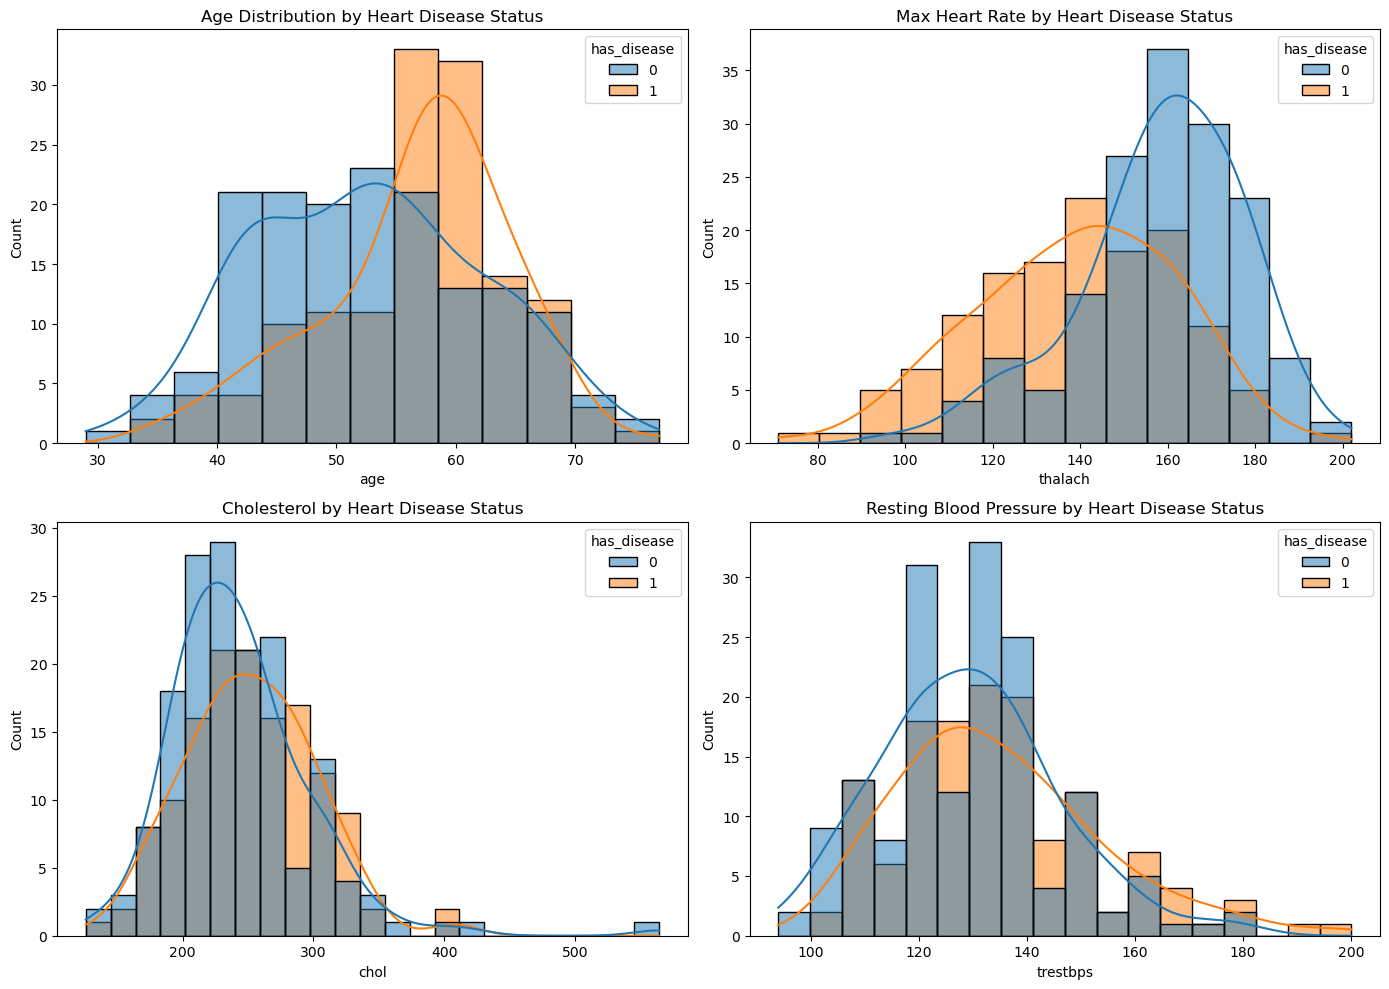

In [45]:
# Let's explore some key features.
print("\nGenerating EDA plots...")

plt.figure(figsize=(14, 10))

# Age distribution
plt.subplot(2, 2, 1)
sns.histplot(data=df_cleaned, x='age', hue='has_disease', kde=True)
plt.title('Age Distribution by Heart Disease Status')

# Max Heart Rate (thalach)
plt.subplot(2, 2, 2)
sns.histplot(data=df_cleaned, x='thalach', hue='has_disease', kde=True)
plt.title('Max Heart Rate by Heart Disease Status')

# Cholesterol (chol)
plt.subplot(2, 2, 3)
sns.histplot(data=df_cleaned, x='chol', hue='has_disease', kde=True)
plt.title('Cholesterol by Heart Disease Status')

# Resting Blood Pressure (trestbps)
plt.subplot(2, 2, 4)
sns.histplot(data=df_cleaned, x='trestbps', hue='has_disease', kde=True)
plt.title('Resting Blood Pressure by Heart Disease Status')

plt.tight_layout()
plt.savefig("heart_disease_histograms.png")
print("Saved heart_disease_histograms.png")

Saved heart_disease_boxplots.png


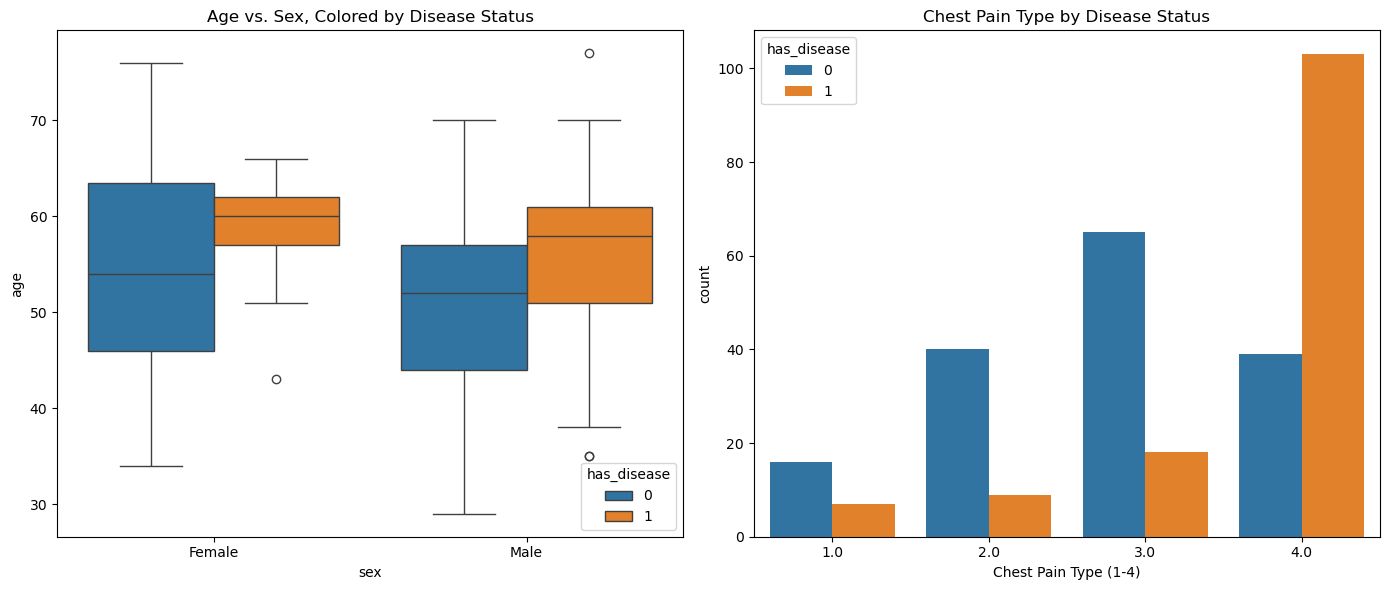

In [46]:
# Boxplots for categorical features
plt.figure(figsize=(14, 6))

# Sex (1=Male, 0=Female) vs. Age
plt.subplot(1, 2, 1)
sns.boxplot(data=df_cleaned, x='sex', y='age', hue='has_disease')
plt.title('Age vs. Sex, Colored by Disease Status')
plt.xticks([0, 1], ['Female', 'Male'])

# Chest Pain Type (cp)
plt.subplot(1, 2, 2)
sns.countplot(data=df_cleaned, x='cp', hue='has_disease')
plt.title('Chest Pain Type by Disease Status')
plt.xlabel('Chest Pain Type (1-4)')

plt.tight_layout()
plt.savefig("heart_disease_boxplots.png")
print("Saved heart_disease_boxplots.png")

### 6. PREPROCESSING

In [47]:
# Separate features (X) from our target (y).
X = df_cleaned.drop('has_disease', axis=1)
y = df_cleaned['has_disease']

In [48]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
# Scale the features
# This is crucial for Logistic Regression.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 7. MODEL TRAINING

In [50]:
# --- Model 1: Logistic Regression ---
# A great baseline model. It's simple, fast, and interpretable.
print("\nTraining Logistic Regression model...")
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained.")


Training Logistic Regression model...
Logistic Regression trained.


In [51]:
# --- Model 2: Random Forest Classifier ---
# A more complex, powerful model. It's an "ensemble" of many
# decision trees and often gives high accuracy.
print("\nTraining Random Forest model...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
print("Random Forest trained.")


Training Random Forest model...
Random Forest trained.


### 8. MODEL EVALUATION

In [52]:
# --- Logistic Regression Evaluation ---
print("\n--- Logistic Regression Results ---")
y_pred_log_reg = log_reg.predict(X_test_scaled)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Accuracy: {accuracy_log_reg * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg, target_names=['No Disease', 'Has Disease']))


--- Logistic Regression Results ---
Accuracy: 83.33%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.82      0.88      0.85        32
 Has Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



Saved log_reg_cm.png


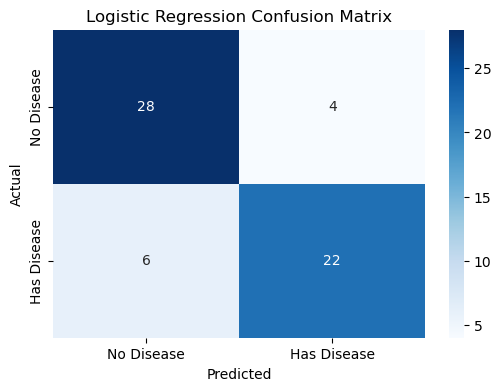

In [53]:
# Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("log_reg_cm.png")
print("Saved log_reg_cm.png")

In [54]:
# --- Random Forest Evaluation ---
print("\n--- Random Forest Results ---")
y_pred_rf = rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {accuracy_rf * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Has Disease']))


--- Random Forest Results ---
Accuracy: 86.67%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.85      0.91      0.88        32
 Has Disease       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



Saved random_forest_cm.png


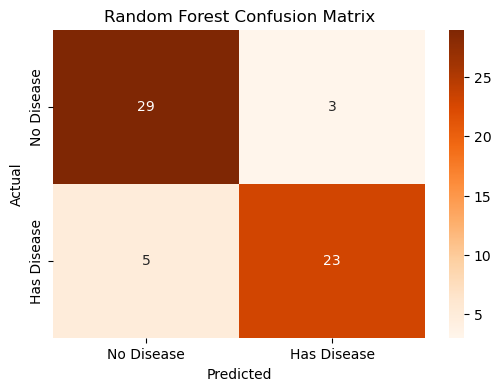

In [55]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("random_forest_cm.png")
print("Saved random_forest_cm.png")

In [56]:
# --- Final Comparison ---
print(f"\nModel Comparison:")
print(f"Logistic Regression Accuracy: {accuracy_log_reg * 100:.2f}%")
print(f"Random Forest Accuracy:     {accuracy_rf * 100:.2f}%")


Model Comparison:
Logistic Regression Accuracy: 83.33%
Random Forest Accuracy:     86.67%


In [57]:
# Discussion:
# Both models are very accurate (often >80%)!
# The Random Forest might be slightly better.
#
# Key discussion point: Look at the confusion matrix.
# - A "False Negative" (Actual=Has Disease, Predicted=No Disease) is VERY BAD. It means we told a sick person they are healthy.
# - A "False Positive" (Actual=No Disease, Predicted=Has Disease) is not great (causes stress, more tests) but is less dangerous.
# - Which model has fewer False Negatives? This is how we choose a model in the real world, not just by overall accuracy!

print("\n--- Project Complete ---")


--- Project Complete ---
